In [1]:
# %%
import os
from typing import List
import cv2
import imageio
import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.optimizers import Adam
from matplotlib import pyplot as plt
import numpy as np


In [2]:
vocab = [x for x in "abcdefghijklmnopqrstuvwxyz'?!123456789 "]

char_to_num = tf.keras.layers.StringLookup(vocabulary=vocab, oov_token="")
num_to_char = tf.keras.layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(), oov_token="", invert=True
)

print(
    f"The vocabulary is: {char_to_num.get_vocabulary()} "
    f"(size ={char_to_num.vocabulary_size()})"
)

def load_video(path:str) -> List[float]: 

    cap = cv2.VideoCapture(path)
    frames = []
    for _ in range(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))): 
        ret, frame = cap.read()
        frame = tf.image.rgb_to_grayscale(frame)
        frames.append(frame[190:236,80:220,:])
    cap.release()
    
    mean = tf.math.reduce_mean(frames)
    std = tf.math.reduce_std(tf.cast(frames, tf.float32))
    return tf.cast((frames - mean), tf.float32) / std

def load_alignments(path:str) -> List[str]: 
    with open(path, 'r') as f: 
        lines = f.readlines() 
    tokens = []
    for line in lines:
        line = line.split()
        if line[2] != 'sil': 
            tokens = [*tokens,' ',line[2]]
    return char_to_num(tf.reshape(tf.strings.unicode_split(tokens, input_encoding='UTF-8'), (-1)))[1:]

def load_data(path: str): 
    path = bytes.decode(path.numpy())
    #file_name = path.split('/')[-1].split('.')[0]
    # File name splitting for windows
    file_name = path.split('\\')[-1].split('.')[0]
    video_path = os.path.join('data','s1',f'{file_name}.mpg')
    alignment_path = os.path.join('data','alignments','s1',f'{file_name}.align')
    frames = load_video(video_path) 
    alignments = load_alignments(alignment_path)
    
    return frames, alignments

def mappable_function(path:str) ->List[str]:
    result = tf.py_function(load_data, [path], (tf.float32, tf.int64))
    return result

The vocabulary is: ['', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', "'", '?', '!', '1', '2', '3', '4', '5', '6', '7', '8', '9', ' '] (size =40)


In [3]:
import numpy as np
import tensorflow as tf
import glob

files = sorted(glob.glob('.././preprocessed_full/batch_*.npz'))

dataset_list = []
for f in files:
    batch = np.load(f)
    frames = tf.convert_to_tensor(batch['frames'], dtype=tf.float32)
    labels = tf.convert_to_tensor(batch['labels'], dtype=tf.int64)
    dataset_list.append((frames, labels))

# Optional: merge batches into a single tf.data.Dataset
frames_all = tf.concat([b[0] for b in dataset_list], axis=0)
labels_all = tf.concat([b[1] for b in dataset_list], axis=0)

data = tf.data.Dataset.from_tensor_slices((frames_all, labels_all))
data = data.batch(2).prefetch(tf.data.AUTOTUNE)


In [4]:
import os, glob

files = sorted(glob.glob('.././preprocessed_full/batch_*.npz'))
print("Found files:", files)


Found files: ['.././preprocessed_full\\batch_0.npz', '.././preprocessed_full\\batch_1.npz', '.././preprocessed_full\\batch_10.npz', '.././preprocessed_full\\batch_100.npz', '.././preprocessed_full\\batch_101.npz', '.././preprocessed_full\\batch_102.npz', '.././preprocessed_full\\batch_103.npz', '.././preprocessed_full\\batch_104.npz', '.././preprocessed_full\\batch_105.npz', '.././preprocessed_full\\batch_106.npz', '.././preprocessed_full\\batch_107.npz', '.././preprocessed_full\\batch_108.npz', '.././preprocessed_full\\batch_109.npz', '.././preprocessed_full\\batch_11.npz', '.././preprocessed_full\\batch_110.npz', '.././preprocessed_full\\batch_111.npz', '.././preprocessed_full\\batch_112.npz', '.././preprocessed_full\\batch_113.npz', '.././preprocessed_full\\batch_114.npz', '.././preprocessed_full\\batch_115.npz', '.././preprocessed_full\\batch_116.npz', '.././preprocessed_full\\batch_117.npz', '.././preprocessed_full\\batch_118.npz', '.././preprocessed_full\\batch_119.npz', '.././pr

In [5]:
# Added for split 
train = data.take(450)
test = data.skip(450)

In [6]:
sample = data.as_numpy_iterator()

In [7]:
val = sample.next(); val[0]

array([[[[[ 1.4315131 ],
          [ 1.4315131 ],
          [ 1.3928236 ],
          ...,
          [ 0.        ],
          [ 0.15475817],
          [ 0.15475817]],

         [[ 1.4315131 ],
          [ 1.4315131 ],
          [ 1.3928236 ],
          ...,
          [ 0.07737909],
          [ 0.        ],
          [ 0.15475817]],

         [[ 1.3928236 ],
          [ 1.3928236 ],
          [ 1.3928236 ],
          ...,
          [ 0.11606863],
          [ 0.11606863],
          [ 0.11606863]],

         ...,

         [[ 0.9672386 ],
          [ 0.9672386 ],
          [ 0.92854905],
          ...,
          [ 9.827144  ],
          [ 9.827144  ],
          [ 9.827144  ]],

         [[ 0.9672386 ],
          [ 0.9672386 ],
          [ 0.92854905],
          ...,
          [ 9.595007  ],
          [ 9.711076  ],
          [ 9.711076  ]],

         [[ 0.9672386 ],
          [ 0.9672386 ],
          [ 0.92854905],
          ...,
          [ 9.595007  ],
          [ 9.672386  ],
          

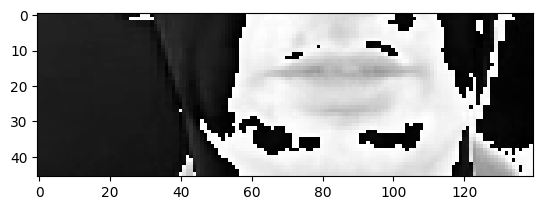

<tf.Tensor: shape=(), dtype=string, numpy=b'lay white with z eight now'>

In [8]:
# %%
# Show first video as GIF
import numpy as np
video = (val[0][0] * 255).astype(np.uint8)  # scale to 0-255
video = np.squeeze(video, axis=-1)
imageio.mimsave('./animation.gif', video, fps=10)

# Show a frame
plt.imshow(val[0][0][35], cmap='gray')
plt.show()

# Decode alignment
tf.strings.reduce_join([num_to_char(word) for word in val[1][0]])


In [9]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv3D, MaxPool3D, BatchNormalization, 
                                     TimeDistributed, Flatten,
                                     Bidirectional, RNN, LSTMCell, Dropout, Dense, Input,
                                     Add, LayerNormalization)

def build_lipreading_model(input_shape=(75,46,140,1), vocab_size=len(vocab)+1):
    """
    Build a 3D-CNN + BiLSTM lip-reading model.
    
    Conv layers run on GPU. BiLSTM layers run on CPU using RNN(LSTMCell) for TF 2.12+.
    """
    inputs = Input(shape=input_shape, name='video_input')
    
    # --- 3D CNN Block 1 ---
    x = Conv3D(64, (3,3,3), padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = MaxPool3D((1,2,2))(x)
    
    # --- 3D CNN Block 2 with residual ---
    x_res = x
    x = Conv3D(128, (3,3,3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv3D(128, (3,3,3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    # Residual channel match
    x_res = Conv3D(128, (1,1,1), padding='same')(x_res)
    x = Add()([x, x_res])
    x = MaxPool3D((1,2,2))(x)
    
    # --- 3D CNN Block 3 ---
    x = Conv3D(256, (3,3,3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPool3D((1,2,2))(x)
    
    # --- Reduce spatial dimensions ---
    x = Conv3D(128, (1,1,1), padding='same', activation='relu')(x)
    x = TimeDistributed(Flatten())(x)
    
    # --- BiLSTM layers on CPU ---
    with tf.device('/CPU:0'):
        # First BiLSTM
        x = Bidirectional(
            RNN(LSTMCell(256, activation='tanh', recurrent_activation='sigmoid'), return_sequences=True)
        )(x)
        x = LayerNormalization()(x)
        x = Dropout(0.5)(x)
        
        # Second BiLSTM
        x = Bidirectional(
            RNN(LSTMCell(256, activation='tanh', recurrent_activation='sigmoid'), return_sequences=True)
        )(x)
        x = LayerNormalization()(x)
        x = Dropout(0.5)(x)
    
    # --- Output layer ---
    outputs = Dense(vocab_size, activation='softmax', kernel_initializer='he_normal', name='char_output')(x)
    
    model = Model(inputs, outputs, name='LipReadingModel')
    return model

# Build model
vocab_size = char_to_num.vocabulary_size() + 1
model = build_lipreading_model(input_shape=(75,46,140,1), vocab_size=vocab_size)

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "LipReadingModel"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 video_input (InputLayer)       [(None, 75, 46, 140  0           []                               
                                , 1)]                                                             
                                                                                                  
 conv3d (Conv3D)                (None, 75, 46, 140,  1792        ['video_input[0][0]']            
                                 64)                                                              
                                                                                                  
 batch_normalization (BatchNorm  (None, 75, 46, 140,  256        ['conv3d[0][0]']                 
 alization)                      64)                                                

In [10]:
yhat = model.predict(val[0])

1/1 [==============================] - 3s 3s/step


In [11]:
tf.strings.reduce_join([num_to_char(tf.argmax(x)) for x in yhat[1]])

<tf.Tensor: shape=(), dtype=string, numpy=b'gsssssssssgggggggdddddddddddddddddeddddddddddddddddddddddtttttt'>

In [12]:
model.input_shape

(None, 75, 46, 140, 1)

In [13]:
model.output_shape

(None, 75, 41)

In [14]:
import math
from tensorflow.keras.callbacks import Callback

class CosineAnnealingScheduler(Callback):
    def __init__(self, max_lr, min_lr, total_epochs, warmup_epochs=5):
        super().__init__()
        self.max_lr = max_lr
        self.min_lr = min_lr
        self.total_epochs = total_epochs
        self.warmup_epochs = warmup_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            # Linear warmup
            lr = self.max_lr * (epoch + 1) / self.warmup_epochs
        else:
            # Cosine decay
            progress = (epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + 0.5 * (self.max_lr - self.min_lr) * (1 + math.cos(math.pi * progress))

        tf.keras.backend.set_value(self.model.optimizer.lr, lr)
        print(f"\nEpoch {epoch+1}: Learning rate set to {lr:.6f}")


In [15]:
def CTCLoss(y_true, y_pred):
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")
    
    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    
    loss = tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)
    return tf.reduce_mean(loss)


In [16]:
import numpy as np
import editdistance

class DecodeAndEvaluate(Callback):
    def __init__(self, dataset, num_to_char, max_steps=5):
        super().__init__()
        self.dataset = dataset.as_numpy_iterator()
        self.num_to_char = num_to_char
        self.max_steps = max_steps

    def on_epoch_end(self, epoch, logs=None):
        data = next(self.dataset)
        yhat = self.model.predict(data[0])
        decoded, _ = tf.keras.backend.ctc_decode(yhat, input_length=[yhat.shape[1]]*yhat.shape[0], greedy=True)

        total_cer, total_wer, count = 0, 0, 0
        for i in range(min(self.max_steps, len(decoded[0]))):
            true = tf.strings.reduce_join(self.num_to_char(data[1][i])).numpy().decode("utf-8")
            pred = tf.strings.reduce_join(self.num_to_char(decoded[0][i])).numpy().decode("utf-8")

            # CER (character error rate)
            total_cer += editdistance.eval(list(pred), list(true)) / max(1, len(true))
            # WER (word error rate)
            total_wer += editdistance.eval(pred.split(), true.split()) / max(1, len(true.split()))
            count += 1

            print(f"\nSample {i+1}")
            print(f" True: {true}")
            print(f" Pred: {pred}")

        print(f"\nEpoch {epoch+1} - CER: {total_cer/count:.3f}, WER: {total_wer/count:.3f}")


In [17]:
class ProduceExample(tf.keras.callbacks.Callback): 
    def __init__(self, dataset) -> None: 
        self.dataset = dataset.as_numpy_iterator()
    
    def on_epoch_end(self, epoch, logs=None) -> None:
        data = self.dataset.next()
        yhat = self.model.predict(data[0])
        decoded = tf.keras.backend.ctc_decode(yhat, [75,75], greedy=False)[0][0].numpy()
        for x in range(len(yhat)):           
            print('Original:', tf.strings.reduce_join(num_to_char(data[1][x])).numpy().decode('utf-8'))
            print('Prediction:', tf.strings.reduce_join(num_to_char(decoded[x])).numpy().decode('utf-8'))
            print('~'*100)

In [25]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss=CTCLoss)
checkpoint_callback = ModelCheckpoint(os.path.join('models','checkpoint'), monitor = 'loss', save_weights_only = True)
# Use your new CosineAnnealingScheduler instead of LearningRateScheduler
total_epochs = 50  # or however many epochs you plan
schedule_callback = CosineAnnealingScheduler(
    max_lr=1e-3,
    min_lr=1e-5,
    total_epochs=4,
    warmup_epochs=1
)

example_callback = ProduceExample(test)


In [26]:
tf.config.experimental.get_memory_info('GPU:0')


{'current': 3899371520, 'peak': 12129013248}

In [32]:
def reshape_videos(x, y):
    # ensure shape: (batch_size, 75, 46, 140, 1)
    x = tf.reshape(x, [-1, 75, 46, 140, 1])
    return x, y

train_fixed = train.map(lambda x, y: (x, y)) \
                   .padded_batch(1, padded_shapes=([75,46,140,1], [None]))
test_fixed = test.map(reshape_videos).batch(1)


ValueError: The padded shape (75, 46, 140, 1) is not compatible with the shape (None, 75, 46, 140, 1) of the corresponding input component.

In [31]:
# Example: training
model.fit(
    train_fixed,            # batch size 1
    validation_data=test.batch(1),
    epochs=4,
    callbacks=[checkpoint_callback, schedule_callback, example_callback]
)


Epoch 1: Learning rate set to 0.001000
Epoch 1/4


ValueError: in user code:

    File "d:\anaconda3\envs\tf-gpu\lib\site-packages\keras\engine\training.py", line 1160, in train_function  *
        return step_function(self, iterator)
    File "d:\anaconda3\envs\tf-gpu\lib\site-packages\keras\engine\training.py", line 1146, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "d:\anaconda3\envs\tf-gpu\lib\site-packages\keras\engine\training.py", line 1135, in run_step  **
        outputs = model.train_step(data)
    File "d:\anaconda3\envs\tf-gpu\lib\site-packages\keras\engine\training.py", line 993, in train_step
        y_pred = self(x, training=True)
    File "d:\anaconda3\envs\tf-gpu\lib\site-packages\keras\utils\traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "d:\anaconda3\envs\tf-gpu\lib\site-packages\keras\engine\input_spec.py", line 295, in assert_input_compatibility
        raise ValueError(

    ValueError: Input 0 o